<a href="https://colab.research.google.com/github/python-is-life2022/Cats-vs-Dogs-Image-Classification-CNN/blob/main/cats_vs_dogs_image_classification_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cats vs Dogs TensorFlow/Keras Dependencies

This document lists the Python environment and imports used by the Cats vs Dogs image-classification project built with TensorFlow/Keras.

## Requirements

- Python 3.10+
- TensorFlow / Keras
- OpenCV
- NumPy
- Matplotlib

## Installation

```bash
python -m pip install --upgrade tensorflow opencv-python numpy matplotlib
```

For Jupyter or Colab:

```bash
!pip install --upgrade tensorflow opencv-python numpy matplotlib
```

Restart the kernel or runtime after installation so the new packages are loaded correctly.


In [61]:
import tensorflow_datasets.core.load as tfds
(train_ds, validation_ds), info = tfds.load('cats_vs_dogs',
                                            split= ['train[:80%]', 'train[80%:]'],
                                            with_info= True,
                                            as_supervised= True)
print(info)

tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings (Conference){asirra-a-captcha-that-exploits-interest-aligned-manual-image-categorization,
    author = {Elson, Jeremy and Douceur, Jo

## Imports Used

In [77]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import optimizers as opt
from keras.models import Sequential
from keras.layers import (Conv2D, MaxPooling2D,
                          GlobalAveragePooling2D, Dense,
                          Dropout, BatchNormalization, Activation)
from keras.losses import binary_crossentropy

In [62]:
print(train_ds)
print(validation_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


In [63]:
print(info.features.keys())

dict_keys(['image', 'image/filename', 'label'])


In [64]:
print(info.features['image'])

Image(shape=(None, None, 3), dtype=uint8)


In [65]:
print(info.splits.keys())
print(f'Train number of samples: {info.splits['train'].num_examples}')

dict_keys(['train'])
Train number of samples: 23262


Image shape: (262, 350, 3)
Label shaep: 1


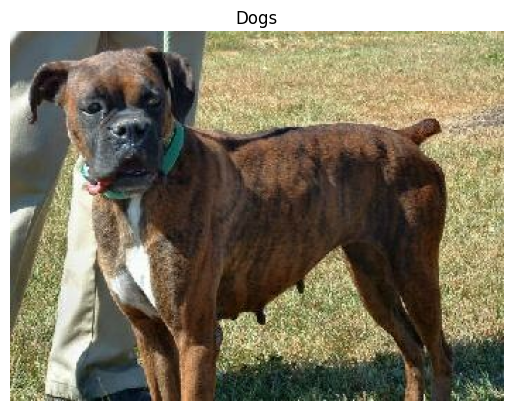

In [66]:
for image, label  in  train_ds.take(1):
    print(f'Image shape: {image.shape}')
    print(f'Label shaep: {label.numpy()}')
    plt.imshow(image)
    plt.title('Dogs' if label.numpy()== 1 else 'Cats')
    plt.axis('off');

## Visualize samples

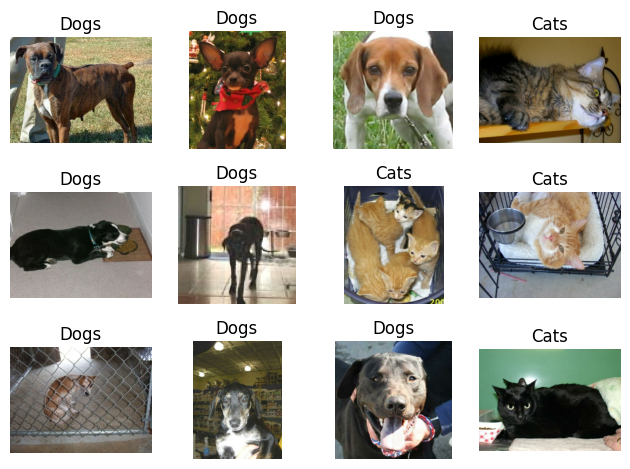

In [67]:
for i, (image, label) in enumerate(train_ds.take(12)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title('Dogs' if label.numpy() == 1 else 'Cats')
    plt.axis('off');

plt.tight_layout()
plt.savefig('cat_and_dog_images_test')
plt.show();

## Preprocess and build the pipeline

In [68]:
def preprocessing_image (image, label):
    image = tf.image.resize(image, (32, 32))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [69]:
train_normal = train_ds.map(preprocessing_image, num_parallel_calls= tf.data.AUTOTUNE)
validation_normal = validation_ds.map(preprocessing_image, num_parallel_calls= tf.data.AUTOTUNE)

In [70]:
train_data = (
    train_normal
    .shuffle(1000)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE))

validation_data = (
    validation_normal
    .batch(32)
    .prefetch(tf.data.AUTOTUNE))


## Data Augmentation

In [73]:
from keras import layers
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

## Model Architecture

In [74]:
model = Sequential([
    data_augmentation,
    Conv2D(64, (3, 3), padding= 'same'),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(64, (3, 3), padding= 'same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.1),
    Conv2D(128, (3, 3), padding= 'same'),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(128, (3, 3), padding= 'same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.15),
    Conv2D(256, (3, 3), padding= 'same'),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(256, (3, 3), padding= 'same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.15),
    GlobalAveragePooling2D(),
    Dense(256, activation= 'relu'),
    Dropout(0.2),
    Dense(1, activation= 'sigmoid')
])

## Model Compilation

In [78]:
model.compile(loss= binary_crossentropy,
              optimizer= opt.Adam(learning_rate= 0.001),
              metrics= ['acc'])

## Model Training & Optimization

In [79]:
his = model.fit(train_data,
                epochs= 60,
                validation_data= validation_data)

Epoch 1/60
582/582 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - acc: 0.6417 - loss: 0.6382 - val_acc: 0.6722 - val_loss: 0.5948
Epoch 2/60
582/582 ━━━━━━━━━━━━━━━━━━━━ 35s 59ms/step - acc: 0.7131 - loss: 0.5590 - val_acc: 0.7154 - val_loss: 0.5285
Epoch 3/60
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - acc: 0.7461 - loss: 0.5153 - val_acc: 0.6724 - val_loss: 0.7432
Epoch 4/60
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - acc: 0.7726 - loss: 0.4758 - val_acc: 0.7829 - val_loss: 0.4628
Epoch 5/60
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - acc: 0.7896 - loss: 0.4525 - val_acc: 0.8141 - val_loss: 0.4044
Epoch 6/60
582/582 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - acc: 0.8041 - loss: 0.4265 - val_acc: 0.7332 - val_loss: 0.5710
Epoch 7/60
582/582 ━━━━━━━━━━━━━━━━━━━━ 35s 48ms/step - acc: 0.8102 - loss: 0.4100 - val_acc: 0.7597 - val_loss: 0.5199
Epoch 8/60
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - acc: 0.8170 - loss: 0.4022 - val_acc: 0.8076 - val_loss: 0.4220
Epoch 9/60
582/582 ━━━━━━━━━━━━━━━━━━━━ 

## 📊 Model Evaluation & Results

In [81]:
train_loss, train_acc = model.evaluate(train_data)
val_loss, val_acc = model.evaluate(validation_data)

print(f'Train Accuracy: {train_acc * 100:.2f}%\nValidation Accuracy: {val_acc * 100:.2f}%'\
      f'\nTrain Loss: {train_loss:.2f}\nValidation Loss: {val_loss:.2f}')

582/582 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - acc: 0.9585 - loss: 0.1058
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - acc: 0.9037 - loss: 0.2638
Train Accuracy: 95.85%
Validation Accuracy: 90.37%
Train Loss: 0.11
Validation Loss: 0.26
